In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('weight-height.csv')

df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


<Axes: >

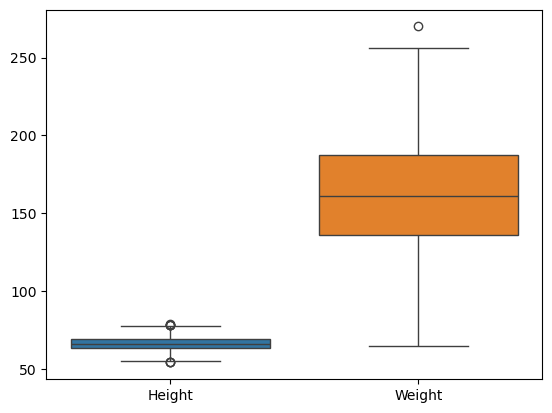

In [3]:
sns.boxplot(df)

<Axes: xlabel='Weight'>

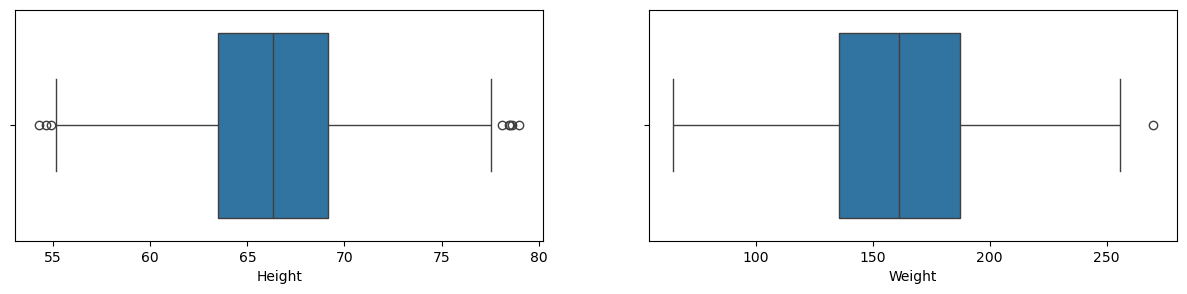

In [4]:
plt.figure(figsize=(15,3))
plt.subplot(1,2,1)
sns.boxplot(x = df['Height'])

plt.subplot(1,2,2)
sns.boxplot(x = df['Weight'])

In [5]:
df.shape

(10000, 3)

In [6]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\Om\AppData\Local\Temp\ipykernel_27372\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

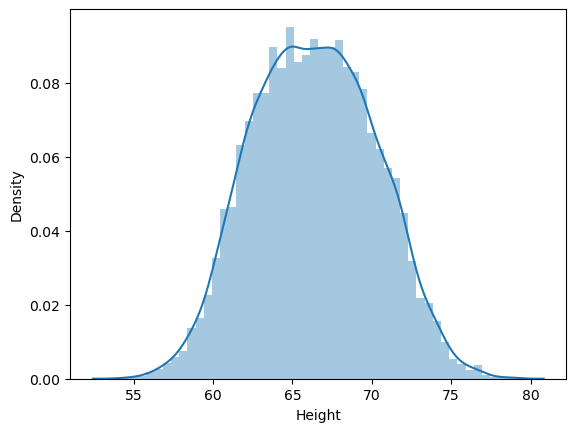

In [7]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

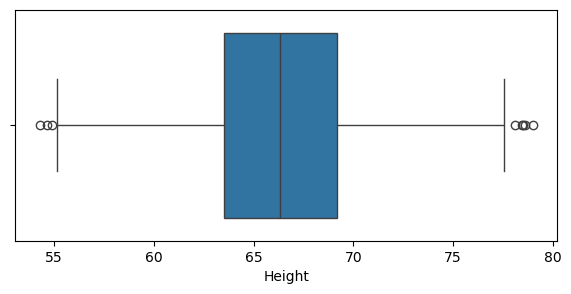

In [9]:
plt.figure(figsize=(7,3))
sns.boxplot(x = df['Height'])

In [10]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01) 

In [11]:
print("Upper Limit :->",upper_limit)
print("Lower Limit :->",lower_limit)

Upper Limit :-> 74.7857900583366
Lower Limit :-> 58.13441158671655


In [14]:
df[(df['Height'] >= upper_limit) | (df['Height'] <= lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# Trimming

In [18]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [19]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


## Comparison

C:\Users\Om\AppData\Local\Temp\ipykernel_27372\122642137.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])
C:\Users\Om\AppData\Local\Temp\ipykernel_27372\122642137.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


Text(0.5, 1.0, 'After New dataframe Distribution of Height')

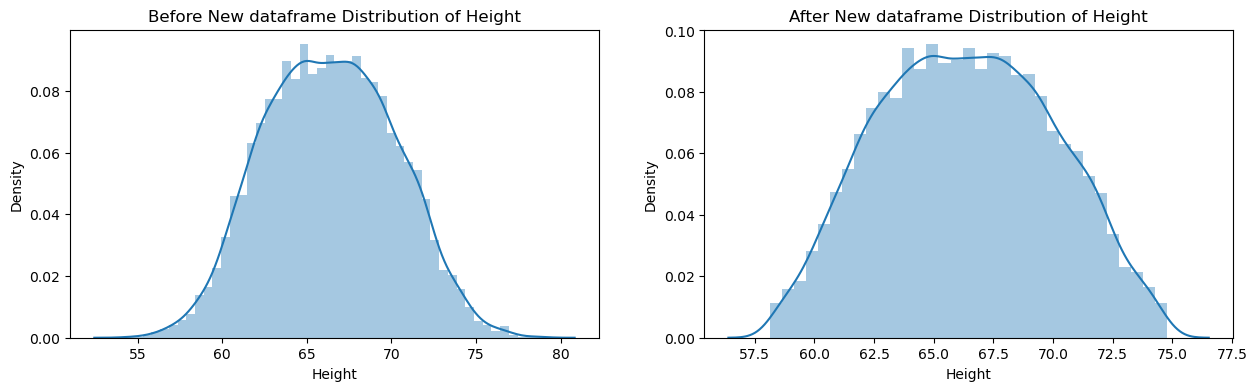

In [22]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.distplot(df['Height'])
plt.title("Before New dataframe Distribution of Height")

plt.subplot(1,2,2)
sns.distplot(new_df['Height'])
plt.title("After New dataframe Distribution of Height")

In [25]:
print(df['Height'].describe())
print()
print(new_df['Height'].describe())

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64


Text(0.5, 1.0, 'After')

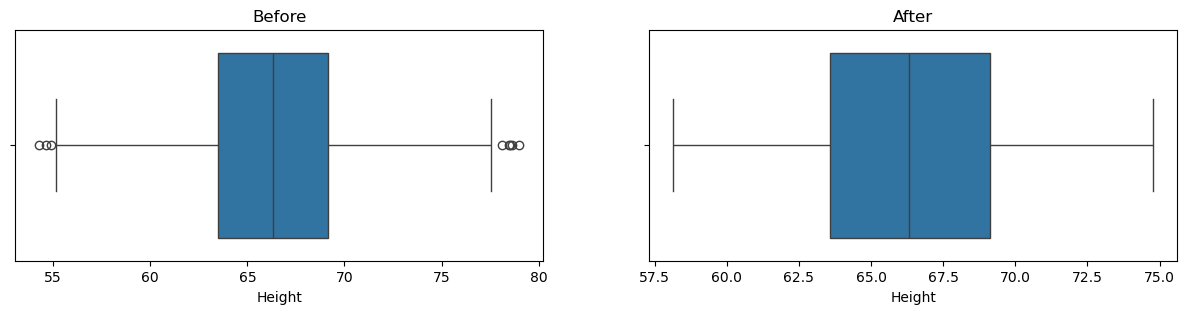

In [29]:
plt.figure(figsize=(15,3))
plt.subplot(1,2,1)
sns.boxplot(x = df['Height'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x = new_df['Height'])
plt.title("After")

# Capping (Winsorization)

In [31]:
df['Height'] = np.where(df['Height'] >= upper_limit, upper_limit, 
        np.where(df['Height'] <= lower_limit, lower_limit, df['Height'])) 

In [32]:
df['Height']

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64

In [34]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

C:\Users\Om\AppData\Local\Temp\ipykernel_27372\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

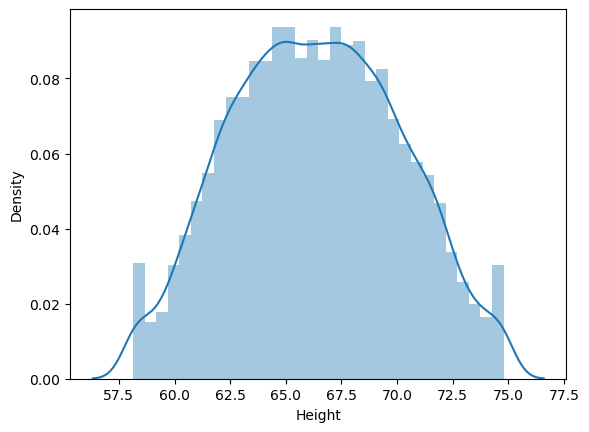

In [35]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

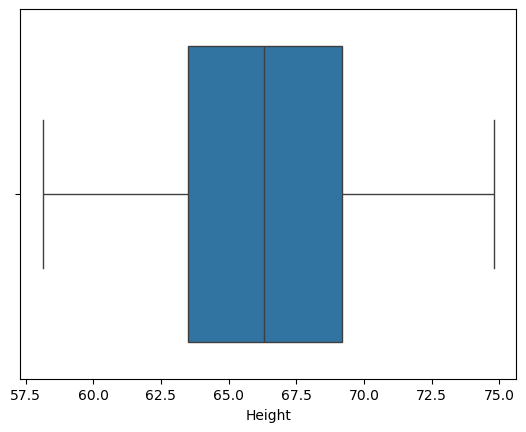

In [37]:
sns.boxplot(x = df['Height'])